# Part 1 : Implementing QPE

## To hand out

1. A **report** with your answers in a **PDF FILE** (made out of LaTeX, libreoffice, ...)
  * Math and text answers
  * The code for the circuits
  * Screenshot of figures/circuits
  * python answers and results of runs
  * *etc*
  
2. **This notebook**
  * as a runnable script

But first, some libraries to load (nothing to modify here)

In [1]:
import numpy as np
from math import pi, gcd
try:
    from qiskit import *
    from qiskit_aer import AerSimulator
    from matplotlib.pyplot import plot,show
except:
    ! python -m pip install matplotlib pylatexenc
    ! python -m pip install qiskit qiskit-aer
from qiskit import *
from qiskit.circuit import *
from qiskit_aer import AerSimulator
from qiskit.circuit.library import *
from qiskit.quantum_info.operators import Operator
from qiskit.compiler import transpile
from qiskit.transpiler import PassManager
from scipy import optimize
from matplotlib.pyplot import plot,show
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # Makes the images look nice

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=abdf731b344d4afcbbabd744ff03a43cc16e243fdf9832e751dbb1f499e35238
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 5.6 MB/s eta 0:00:00


# 0 - Before anything else

### Make sure you checked the notebook TP-Intro-QisKit


# 1 - Small practice

To start, check that when we measure $\frac1{\sqrt2}(|000\rangle+|111\rangle)$ we indeed get 000 and 111 about the same number of times.

{'000': 497, '111': 503}


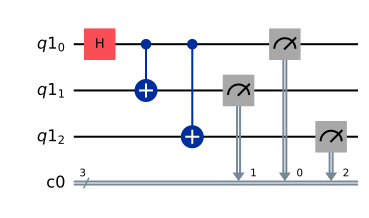

In [2]:
# Generating the circuit

q = QuantumRegister(3)   # We need 3 qubits..
c = ClassicalRegister(3) # ... and 3 bits to store the results
qc = QuantumCircuit(q,c) # the circuit !

# Bell state
qc.h(q[0])
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])

qc.measure(q, c)

# Simulate the circuit
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
job = simulator.run(transpiled_qc, shots=1000)
result = job.result()
counts = result.get_counts()
print(counts)


qc.draw('mpl')

#### Write record what you did and what you see in the separate report

# 2 - QPE

We've seen the QPE algorithm in the course, and you checked it worked with 3 qubits. Here we are going to implement it with the following unitary:

In [3]:
U = UnitaryGate(
    Operator([[1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,np.exp(pi*2j*(3/8))]]), label="U")

## Questions

###  Q 2.1 Math questions

* What is this operator doing ? (`2j` is in Python the complex number $2\cdot i$)
* On how many qubits does it act ?
* What are its eigenvalues/eigenvectors ?
* For each eigenvector, what should QPE return with 3 bits of precisions, as seen in the course ?

#### Give answers and explanations in the separate report

### Q 2.2 Implementing QPE

Below a template to fill in for
- realize QPE with 3 bits of precision.
- on the eigenvector of non-trivial eigenvalue

We initialized a quantum circuit with 3 registers:
 - `eig` for storing the eigenvalues
 - `phi` for storing the eigenvector
 - `ceig` for storing the result of the measurement of the eigenvalue-register.

Note that we only need to measure the eigenvalues!

What you will need:
 - `QFT(size)` build for you a QFT on `size` qubits.
 - `U.control()` for controlling a gate `U`. The control qubit should be placed first in the list of wires.
 - `U.inverse()` for the inverse of the gate `U`.
 - `U.power(p)` add `p` times `U` on the circuit.
 - `qc.append(U, list_of_qubits)` applies the gate `U` on the list of qubits.
 - Beware : `phi` (for instance) is not a list but a register. So if you want to concatenate it with something else, you first have to make a list out of it with `list(phi)`.

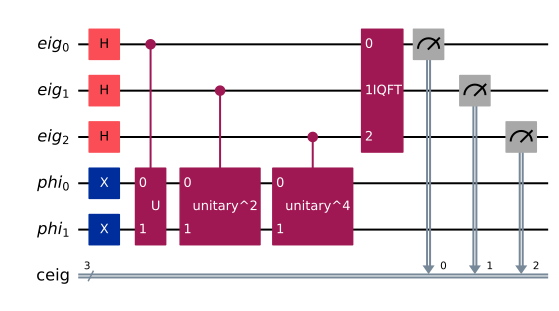

In [4]:
size_eig = 3
# size_eig = 4
# size_eig = 5 # number of qubits
size_phi = 2

eig = QuantumRegister(size_eig, name="eig")
phi = QuantumRegister(size_phi, name="phi")
ceig = ClassicalRegister(size_eig, name="ceig")
qc = QuantumCircuit(eig,phi,ceig)

# phi in |11> state
qc.x(phi[0])
qc.x(phi[1])

qc.h(eig)

# C-U, C-U^2, C-U^4, C-U^8, C-U^16
qc.append(U.control(), [eig[0]] + list(phi))
qc.append(U.power(2).control(), [eig[1]] + list(phi))
qc.append(U.power(4).control(), [eig[2]] + list(phi))
# qc.append(U.power(8).control(), [eig[3]] + list(phi))
# qc.append(U.power(16).control(), [eig[4]] + list(phi))

# Inverse QFT
qc.append(QFT(size_eig).inverse(), eig)

qc.measure(eig,ceig)

qc.draw('mpl')

# First, make sure that the drawing is OK.

In [5]:
# Then run the backend !

simulator = AerSimulator()
job = simulator.run(qc.decompose(reps=6), shots=1024)
res = dict(job.result().get_counts(qc))
res

{'011': 1024}

### Q 2.3 Exact result

- (a) Is it the expected result ?
- (b) Change the $\frac68$ of the phase of $U$: use $\frac18$, then $\frac28$... Is QPE returning the correct answer?
- (c) Change the precision : use $4$ qubits for `eig`, and change the fraction in the phase of $U$ to $\frac{10}{16}$ : is QPE indeed returning $10$ in binary ?
- (d) Move to $5$ bits of précision: is it still working ?

#### Give answers and explanations in the separate report

### Q 2.4 Approximate result

Use  $\frac13$ in the phase of $U$:
- With 3 bits of precision
- With 4 bits of precision
- With 5 bits of precision

**Question** What do you observe? Can you explain it? What do you read?

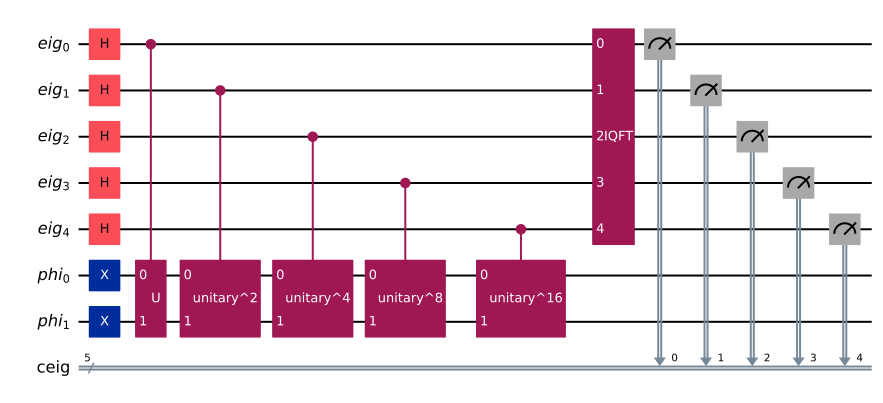

In [6]:
U = UnitaryGate(
    Operator([[1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,np.exp(pi*2j*(1/3))]]), label="U")

# size_eig = 3
# size_eig = 4
size_eig = 5
size_phi = 2

eig = QuantumRegister(size_eig, name="eig")
phi = QuantumRegister(size_phi, name="phi")
ceig = ClassicalRegister(size_eig, name="ceig")
qc = QuantumCircuit(eig,phi,ceig)

qc.x(phi[0])
qc.x(phi[1])

qc.h(eig)

qc.append(U.control(), [eig[0]] + list(phi))
qc.append(U.power(2).control(), [eig[1]] + list(phi))
qc.append(U.power(4).control(), [eig[2]] + list(phi))
qc.append(U.power(8).control(), [eig[3]] + list(phi))
qc.append(U.power(16).control(), [eig[4]] + list(phi))

qc.append(QFT(size_eig).inverse(), eig)

qc.measure(eig,ceig)

qc.draw('mpl')

# First, make sure that the drawing is OK.

In [7]:
# Then run the backend !

simulator = AerSimulator()
job = simulator.run(qc.decompose(reps=6), shots=1024)
res = dict(job.result().get_counts(qc))
res

{'00010': 1,
 '00000': 1,
 '10100': 1,
 '10110': 1,
 '11111': 2,
 '11000': 1,
 '10011': 3,
 '01101': 15,
 '01010': 165,
 '01011': 703,
 '00011': 2,
 '00111': 8,
 '01100': 45,
 '00100': 3,
 '10000': 6,
 '01110': 8,
 '00101': 2,
 '01001': 22,
 '10001': 6,
 '00001': 1,
 '10111': 1,
 '10101': 3,
 '10010': 5,
 '01000': 12,
 '00110': 4,
 '01111': 3}

#### Give answers and explanations in the separate report

### Q 2.5 Superposition

We saw that the circuit of QPE has no problem with a superposition of eigenvectors. Try to change the initialization of `phi` with
$$
\frac1{\sqrt2}(|\phi_1\rangle + |\phi_2\rangle),
$$
two eigenvectors of $U$ (one with trivial eigenvalue, the other one non-trivial).

Also measure the register `phi` at the end of the circuit, and analyze the result: can you explain what you see?

Try this experiment with phase $\frac38$ and $\frac13$.

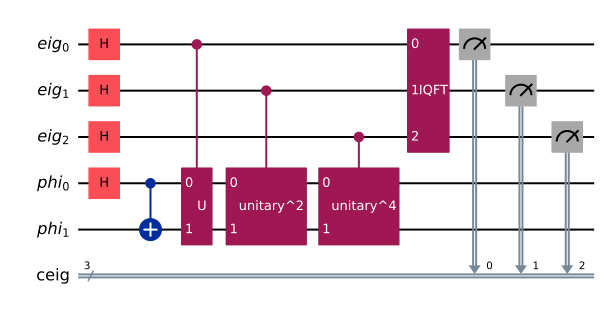

In [9]:
U = UnitaryGate(
    Operator([[1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,np.exp(pi*2j*(3/8))]]), label="U")

size_eig = 3
size_phi = 2

eig = QuantumRegister(size_eig, name="eig")
phi = QuantumRegister(size_phi, name="phi")
ceig = ClassicalRegister(size_eig, name="ceig")
qc = QuantumCircuit(eig, phi, ceig)

# Bell state with superposition
qc.h(phi[0])
qc.cx(phi[0], phi[1])

qc.h(eig)

qc.append(U.control(), [eig[0]] + list(phi))
qc.append(U.power(2).control(), [eig[1]] + list(phi))
qc.append(U.power(4).control(), [eig[2]] + list(phi))

qc.append(QFT(size_eig).inverse(), eig)

qc.measure(eig, ceig)

qc.draw('mpl')

In [10]:
simulator = AerSimulator()
job = simulator.run(qc.decompose(reps=6), shots=1024)
res = dict(job.result().get_counts(qc))
res

{'011': 509, '000': 515}

#### Give answers and explanations in the separate report